# 03 — CIFAR patch-bags: imagens VISÍVEIS na bag

Aqui resolvemos a limitação do Tiger/Elephant: cada instância **é uma imagem RGB que dá pra ver**. Uma bag é um conjunto de imagens CIFAR-10; a bag é **positiva** se contém pelo menos uma imagem da **classe-alvo**.

Como nós montamos a bag, sabemos exatamente quais instâncias são a testemunha (`instance_labels`) → a **métrica de localização volta a valer**, e dá pra fazer figuras de interpretabilidade.

In [1]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt

from hopmil.data import CIFARBags
from hopmil.data.cifar_bags import CIFAR10_CLASSES
from hopmil.models import CNNEncoder, build_aggregator, MILClassifier
from hopmil.eval.metrics import instance_localization_auc

TARGET = 0  # 0=airplane ... veja CIFAR10_CLASSES
print('classes:', CIFAR10_CLASSES)
ds = CIFARBags(root='../data/raw', target_class=TARGET, mean_bag_size=8,
               num_bags=80, seed=0)
print('classe-alvo:', ds.target_name)

classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
classe-alvo: airplane


## Parte 1 — Ver o conjunto e UMA bag

In [2]:
labels = [int(b.label) for b in ds.bags]
print(f'n bags  : {len(ds)}  (+{sum(labels)} / -{len(labels)-sum(labels)})')
bag = next(b for b in ds.bags if int(b.label) == 1)
print(f'bag.instances       -> {tuple(bag.instances.shape)}  (n imagens, 3 canais, 32x32)')
print(f'bag.label           -> {bag.label.item()}')
print(f'bag.instance_labels -> {bag.instance_labels.tolist()}  (1 = imagem da classe-alvo)')

n bags  : 80  (+46 / -34)
bag.instances       -> (6, 3, 32, 32)  (n imagens, 3 canais, 32x32)
bag.label           -> 1
bag.instance_labels -> [0, 0, 0, 0, 1, 0]  (1 = imagem da classe-alvo)


### Visualizar a bag — os crops de verdade
Borda **verde** = imagem da classe-alvo (a testemunha que torna a bag positiva).

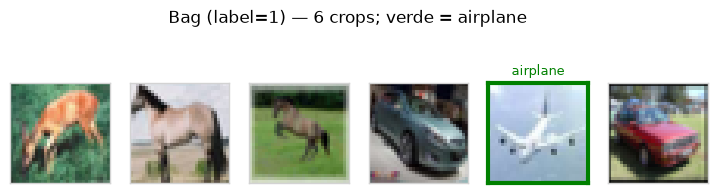

In [4]:
imgs = CIFARBags.denormalize(bag.instances).permute(0, 2, 3, 1)  # (n,32,32,3) em [0,1]
n = imgs.shape[0]
fig, axes = plt.subplots(1, n, figsize=(1.5 * n, 1.8))
for i, ax in enumerate(axes):
    tgt = bag.instance_labels[i].item() == 1
    ax.imshow(imgs[i])
    ax.set_title(ds.target_name if tgt else '', color='green', fontsize=9)
    for s in ax.spines.values():
        s.set_color('green' if tgt else 'lightgray'); s.set_linewidth(3 if tgt else 1)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f'Bag (label={bag.label.item()}) — {n} crops; verde = {ds.target_name}', y=1.18)
plt.show()

## Parte 2 — A bag atravessando a rede (CNN RGB)
Mesma pipeline; encoder = `CNNEncoder(in_channels=3, image_size=32)`.

In [5]:
DIM = 128
encoder = CNNEncoder(dim=DIM, in_channels=3, image_size=32)
aggregator = build_aggregator('attention', dim=DIM)
clf = MILClassifier(encoder, aggregator, num_classes=1, dim=DIM).eval()

with torch.no_grad():
    x = bag.instances
    print('1) entrada      :', tuple(x.shape))
    emb = encoder(x); print('2) apos encoder :', tuple(emb.shape))
    z, w = aggregator(emb); print('3) vetor da bag :', tuple(z.shape), '| weights', tuple(w.shape))
    prob = torch.sigmoid(clf.head(z))
    print('4) probabilidade:', round(prob.item(), 3), '(rede sem treino)')

1) entrada      : (6, 3, 32, 32)
2) apos encoder : (6, 128)
3) vetor da bag : (128,) | weights (6,)
4) probabilidade: 0.515 (rede sem treino)


## Parte 3 — Interpretabilidade: a atenção aponta para a testemunha?
Comparamos os pesos com `instance_labels`. **Sem treino**, fica perto do acaso — o objetivo do artigo é ver isso melhorar e comparar entre os 4 agregadores.

In [5]:
auc = instance_localization_auc(w, bag.instance_labels)
print(f'localizacao AUC (sem treino): {auc:.3f}\n')
order = torch.argsort(w, descending=True)
for rank, i in enumerate(order.tolist()):
    flag = f'  <-- {ds.target_name.upper()} (alvo)' if bag.instance_labels[i].item() == 1 else ''
    print(f'  #{rank+1}  inst {i:2d}  peso={w[i].item():.3f}{flag}')

localizacao AUC (sem treino): 0.000

  #1  inst  0  peso=0.170
  #2  inst  2  peso=0.169
  #3  inst  5  peso=0.167
  #4  inst  3  peso=0.167
  #5  inst  1  peso=0.164
  #6  inst  4  peso=0.163  <-- AIRPLANE (alvo)


## Resumo

- **CIFAR patch-bags** dá o que faltava: instâncias que são imagens visíveis **e** testemunhas conhecidas.
- Os 3 datasets cobrem ângulos complementares: **MNIST-bags** (cinza, simples), **CIFAR-bags** (RGB, realista), **Tiger/Elephant/Fox** (tabular, benchmark padrão).
- Mesma pipeline `encoder → agregador → head` nos três — é o que permite comparar os 4 agregadores de forma justa.